# Compression Robustness — Automated vs Manual

Second robustness test comparing UR5e-automated and manual Instron compression: mean±SD loading bands, Welch's t-test at 10/20/25% strain, and TOST equivalence (±0.05 MPa margin).

In [1]:
%config InlineBackend.figure_formats = ['svg']

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

sys.path.insert(0, 'auto_compression')
from parser import parse_continuous_csv
from extraction import extract_stress_at_target

DATA_CSV = Path('auto_compression/Robustness Test - Compression (Second Test)(Raw .csv')
PLOT_DIR = Path('plots/compression')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

CHECK_POINTS = [10.0, 20.0, 25.0]   # relative-strain check-points (%)
TOST_DELTA   = 0.05                 # MPa equivalence margin (a priori, domain-justified)

COLOR_AUTO   = '#E64B35'  # NPG red
COLOR_MANUAL = '#3C5488'  # NPG blue

plt.rcParams.update({
    'font.family': 'Arial', 'font.sans-serif': ['Arial'],
    'font.size': 16, 'axes.labelsize': 16, 'axes.titlesize': 12,
    'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.labelsize': 16, 'ytick.labelsize': 16,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'xtick.major.width': 0.8, 'ytick.major.width': 0.8,
    'xtick.major.size': 3, 'ytick.major.size': 3,
    'legend.fontsize': 14, 'legend.frameon': False, 'lines.linewidth': 1.2,
    'savefig.dpi': 300, 'savefig.bbox': 'tight', 'savefig.transparent': True,
    'svg.fonttype': 'none',
})


In [2]:
events = parse_continuous_csv(DATA_CSV)
print(f'{len(events)} compression events detected')

# Positional grouping (acquisition order): drop event 1 (preconditioning).
AUTO_EVENTS   = list(range(2, 12))    # events 2-11  (automated / UR5e)
MANUAL_EVENTS = list(range(12, 22))   # events 12-21 (manual)
by_num = {e.specimen_num: e for e in events}

auto_sel   = [by_num[n] for n in AUTO_EVENTS]
manual_sel = [by_num[n] for n in MANUAL_EVENTS]
GROUPS = [('auto', auto_sel), ('manual', manual_sel)]

for label, sel in GROUPS:
    print(f'== {label}: {len(sel)} events {[e.specimen_num for e in sel]}')
    for e in sel:
        print(f'   event {e.specimen_num}: contact->peak rel-strain={e.strain.iloc[-1]:.2f}%, '
              f'peak stress={e.stress.iloc[-1]:.4f} MPa, n={len(e.stress)}')

21 compression events detected
== auto: 10 events [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
   event 2: contact->peak rel-strain=31.89%, peak stress=0.2655 MPa, n=196
   event 3: contact->peak rel-strain=31.07%, peak stress=0.2734 MPa, n=191
   event 4: contact->peak rel-strain=35.39%, peak stress=0.2950 MPa, n=217
   event 5: contact->peak rel-strain=37.88%, peak stress=0.2476 MPa, n=232
   event 6: contact->peak rel-strain=33.39%, peak stress=0.2743 MPa, n=205
   event 7: contact->peak rel-strain=37.22%, peak stress=0.2346 MPa, n=228
   event 8: contact->peak rel-strain=33.56%, peak stress=0.3110 MPa, n=206
   event 9: contact->peak rel-strain=32.41%, peak stress=0.2716 MPa, n=199
   event 10: contact->peak rel-strain=35.39%, peak stress=0.2739 MPa, n=217
   event 11: contact->peak rel-strain=35.24%, peak stress=0.3021 MPa, n=216
== manual: 10 events [12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
   event 12: contact->peak rel-strain=35.56%, peak stress=0.2767 MPa, n=218
   event 13: contact->peak 

In [3]:
rows = []
for label, sel in GROUPS:
    for e in sel:
        out = extract_stress_at_target(e.strain, e.stress, start_x=0.0,
                                       x_signal=CHECK_POINTS, tolerance=0.5)
        for x in CHECK_POINTS:
            target_x, y = out[x]
            assert not np.isnan(y), (f'{label} event {e.specimen_num} could not reach '
                                     f'{x}% rel-strain (peak {e.strain.iloc[-1]:.1f}%)')
            rows.append({'group': label, 'event': e.specimen_num, 'x_rel': x, 'stress': y})

stress_df = pd.DataFrame(rows)
stress_df

,group,event,x_rel,stress
0,auto,2,10.0,0.1083
1,auto,2,20.0,0.1781
2,auto,2,25.0,0.2134
3,auto,3,10.0,0.0869
4,auto,3,20.0,0.1735
5,auto,3,25.0,0.2223
6,auto,4,10.0,0.0986
7,auto,4,20.0,0.1694
8,auto,4,25.0,0.2008
9,auto,5,10.0,0.0806


## Difference test — Welch's t-test (Holm-corrected)

In [4]:
def stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'


def holm_bonferroni(pvals):
    """Holm-Bonferroni step-down adjusted p-values (monotone, capped at 1)."""
    pvals = np.asarray(pvals, float)
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m)
    running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, (m - rank) * pvals[idx])
        adj[idx] = min(running, 1.0)
    return adj


stat_rows = []
for x in CHECK_POINTS:
    a = stress_df[(stress_df['group'] == 'auto')   & (stress_df['x_rel'] == x)]['stress'].values
    m = stress_df[(stress_df['group'] == 'manual') & (stress_df['x_rel'] == x)]['stress'].values
    welch = stats.ttest_ind(a, m, equal_var=False)
    stat_rows.append({
        'x_rel (%)': x,
        'auto mean': a.mean(),   'auto SD':   a.std(ddof=1),
        'manual mean': m.mean(), 'manual SD': m.std(ddof=1),
        'Welch t': welch.statistic, 'Welch p': welch.pvalue,
    })

stat_df = pd.DataFrame(stat_rows)
stat_df['Holm p'] = holm_bonferroni(stat_df['Welch p'].values)
stat_df['sig'] = [stars(p) for p in stat_df['Holm p']]

with pd.option_context('display.float_format', '{:.4f}'.format):
    print(stat_df.to_string(index=False))
stat_df

 x_rel (%)  auto mean  auto SD  manual mean  manual SD  Welch t  Welch p  Holm p sig
   10.0000     0.0930   0.0127       0.0859     0.0184   1.0066   0.3291  0.6648  ns
   20.0000     0.1598   0.0113       0.1527     0.0137   1.2678   0.2216  0.6648  ns
   25.0000     0.1937   0.0188       0.1910     0.0275   0.2483   0.8071  0.8071  ns


,x_rel (%),auto mean,auto SD,manual mean,manual SD,Welch t,Welch p,Holm p,sig
0,10.0,0.09298,0.012728,0.08586,0.018392,1.006638,0.329080,0.664798,ns
1,20.0,0.15980,0.011323,0.15267,0.013714,1.267786,0.221599,0.664798,ns
2,25.0,0.19367,0.018848,0.19105,0.027540,0.248266,0.807104,0.807104,ns


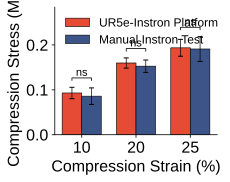

In [5]:
def plot_stress_bars(ax, stress_df, stat_df):
    xs = np.arange(len(CHECK_POINTS))
    width = 0.36
    for offset, group, color, lab in [(-width / 2, 'auto',   COLOR_AUTO,   'UR5e-Instron Platform'),
                                      (+width / 2, 'manual', COLOR_MANUAL, 'Manual Instron Test')]:
        sub = stress_df[stress_df['group'] == group]
        means = [sub[sub['x_rel'] == x]['stress'].mean() for x in CHECK_POINTS]
        sds = [sub[sub['x_rel'] == x]['stress'].std(ddof=1) for x in CHECK_POINTS]
        ax.bar(xs + offset, means, width=width, color=color, edgecolor='black',
               linewidth=0.6, label=lab, yerr=sds, capsize=2.5,
               error_kw={'elinewidth': 0.7, 'ecolor': 'black'})

    # per-bar-pair tops (mean + SD) for placing significance brackets
    tops = []
    for x in CHECK_POINTS:
        row = stat_df[stat_df['x_rel (%)'] == x].iloc[0]
        tops.append(max(row['auto mean'] + row['auto SD'],
                        row['manual mean'] + row['manual SD']))
    ymax = max(tops)
    ax.set_ylim(0, ymax * 1.30)

    # pairwise auto-vs-manual significance bracket + label at each check-point
    h = ymax * 0.025
    for i, x in enumerate(CHECK_POINTS):
        sig = stat_df[stat_df['x_rel (%)'] == x].iloc[0]['sig']
        y = tops[i] + ymax * 0.07
        x1, x2 = xs[i] - width / 2, xs[i] + width / 2
        ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=0.8, c='black')
        ax.text(xs[i], y + h, sig, ha='center', va='bottom', fontsize=11)

    ax.set_xticks(xs)
    ax.set_xticklabels([int(x) for x in CHECK_POINTS])
    ax.set_xlabel('Compression Strain (%)')
    ax.set_ylabel('Compression Stress (MPa)')
    ax.legend(loc='upper left', fontsize=12)


fig, ax = plt.subplots(figsize=(3.4, 2.8))
plot_stress_bars(ax, stress_df, stat_df)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'robust2_bars.svg')
plt.show()

## Equivalence test — TOST (±0.05 MPa)

In [6]:
def welch_diff_ci(a, b, alpha=0.10):
    a = np.asarray(a, float); b = np.asarray(b, float)
    diff = a.mean() - b.mean()
    va, vb = a.var(ddof=1), b.var(ddof=1)
    na, nb = len(a), len(b)
    se = np.sqrt(va / na + vb / nb)
    df = (va / na + vb / nb) ** 2 / ((va / na) ** 2 / (na - 1) + (vb / nb) ** 2 / (nb - 1))
    t_crit = stats.t.ppf(1 - alpha / 2, df)
    return diff, diff - t_crit * se, diff + t_crit * se, se, df


def tost(a, b, delta):
    a = np.asarray(a, float); b = np.asarray(b, float)
    diff, _, _, se, df = welch_diff_ci(a, b)
    p_lower = 1 - stats.t.cdf((diff + delta) / se, df)
    p_upper = stats.t.cdf((diff - delta) / se, df)
    return max(p_lower, p_upper)


tost_rows = []
for x in CHECK_POINTS:
    a = stress_df[(stress_df['group'] == 'auto')   & (stress_df['x_rel'] == x)]['stress'].values
    m = stress_df[(stress_df['group'] == 'manual') & (stress_df['x_rel'] == x)]['stress'].values
    diff, lo, hi, _, _ = welch_diff_ci(a, m, alpha=0.10)  # 90% CI
    p = tost(a, m, TOST_DELTA)
    tost_rows.append({
        'x_rel (%)': x, 'diff (auto-man)': diff,
        '90% CI lo': lo, '90% CI hi': hi, 'TOST p': p,
        f'equiv (δ={TOST_DELTA})': p < 0.05,
    })

tost_df = pd.DataFrame(tost_rows)
with pd.option_context('display.float_format', '{:.4f}'.format):
    print(tost_df.to_string(index=False))
tost_df

 x_rel (%)  diff (auto-man)  90% CI lo  90% CI hi  TOST p  equiv (δ=0.05)
   10.0000           0.0071    -0.0052     0.0195  0.0000            True
   20.0000           0.0071    -0.0026     0.0169  0.0000            True
   25.0000           0.0026    -0.0158     0.0211  0.0002            True


,x_rel (%),diff (auto-man),90% CI lo,90% CI hi,TOST p,equiv (δ=0.05)
0,10.0,0.00712,-0.005228,0.019468,8.205586e-06,True
1,20.0,0.00713,-0.002641,0.016901,3.039540e-07,True
2,25.0,0.00262,-0.015811,0.021051,1.880601e-04,True


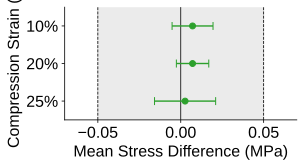

In [7]:
def plot_equivalence(ax, tost_df, delta):
    ys = np.arange(len(tost_df))[::-1]
    diffs = tost_df['diff (auto-man)'].values
    los = tost_df['90% CI lo'].values
    his = tost_df['90% CI hi'].values
    ax.axvspan(-delta, +delta, color='#cccccc', alpha=0.4, zorder=0,
               label=f'Equivalence band ±{delta} MPa')
    ax.axvline(0, color='black', lw=0.8, zorder=1)
    ax.axvline(-delta, color='black', lw=0.8, ls='--', zorder=1)
    ax.axvline(+delta, color='black', lw=0.8, ls='--', zorder=1)
    for y, d, lo, hi in zip(ys, diffs, los, his):
        inside = (lo >= -delta) and (hi <= +delta)
        color = '#2ca02c' if inside else '#d62728'
        ax.errorbar(d, y, xerr=[[d - lo], [hi - d]], fmt='o', color=color, ecolor=color,
                    elinewidth=1.4, capsize=4, markersize=6, zorder=3)
    ax.set_yticks(ys)
    ax.set_yticklabels([f'{int(x)}%' for x in tost_df['x_rel (%)']])
    ax.set_ylim(ys.min() - 0.5, ys.max() + 0.5)
    ax.set_xlabel('Mean Stress Difference (MPa)')
    ax.set_ylabel('Compression Strain (%)')
    xpad = max(delta * 1.4, np.abs(np.r_[los, his]).max() * 1.2)
    ax.set_xlim(-xpad, +xpad)


fig, ax = plt.subplots(figsize=(4.5, 2.6))
plot_equivalence(ax, tost_df, TOST_DELTA)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'robust2_equivalence.svg')
plt.show()

## Mean ± 1 SD loading curves

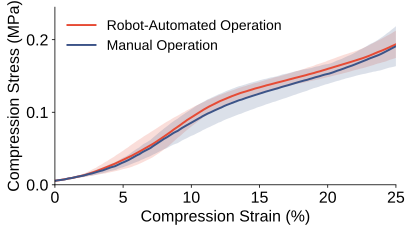

In [8]:
# Common strain grid: 0->25%. Every one of the 20 events reaches >=27.7% rel-strain
# (min is manual event 18 at 27.72%), so the whole grid is interpolated, never extrapolated.
STRAIN_GRID = np.linspace(0.0, 25.0, 251)   # 0.1% spacing


def mean_sd_band(sel, grid):
    """Interpolate each event's stress onto the common strain grid, then return the
    across-replicate mean and 1 SD (ddof=1, matching the reported check-point SDs)."""
    stacked = np.vstack([np.interp(grid, e.strain, e.stress) for e in sel])
    return stacked.mean(axis=0), stacked.std(axis=0, ddof=1)


auto_mean,   auto_sd   = mean_sd_band(auto_sel,   STRAIN_GRID)
manual_mean, manual_sd = mean_sd_band(manual_sel, STRAIN_GRID)

fig, ax = plt.subplots(figsize=(6, 3.5))
for mean, sd, color, lab in [
    (auto_mean,   auto_sd,   COLOR_AUTO,   'Robot-Automated Operation'),
    (manual_mean, manual_sd, COLOR_MANUAL, 'Manual Operation'),
]:
    ax.fill_between(STRAIN_GRID, mean - sd, mean + sd,
                    color=color, alpha=0.18, linewidth=0, zorder=1)
    ax.plot(STRAIN_GRID, mean, color=color, lw=2.0, label=lab, zorder=2)

ax.set_xlabel('Compression Strain (%)')
ax.set_ylabel('Compression Stress (MPa)')
ax.set_xlim(0, 25)
ax.set_xticks([0, 5, 10, 15, 20, 25])
band_top = max((auto_mean + auto_sd).max(), (manual_mean + manual_sd).max())
ax.set_ylim(0, band_top * 1.12)
ax.set_yticks([0.0, 0.1, 0.2])
ax.legend(loc='upper left')

fig.tight_layout()
fig.savefig(PLOT_DIR / 'robust2_mean_band.svg')
plt.show()